# Bone Age Estimation - Optimized Pipeline for Kaggle

Optimized parameters for better accuracy with GPU acceleration on Kaggle.

In [15]:
# ======================================================================
# KAGGLE DATASET REFERENCE
# ======================================================================

import os
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/kmader/rsna-bone-age')

TRAIN_DIR = DATA_DIR / 'boneage-training-dataset/boneage-training-dataset'
TEST_DIR  = DATA_DIR / 'boneage-test-dataset/boneage-test-dataset'

print(f'Data directory: {DATA_DIR}')
if TRAIN_DIR.exists():
    print(f'✅ Train: {TRAIN_DIR} — {len(os.listdir(TRAIN_DIR))} fichiers')
else:
    print('❌ Train directory not found')

if TEST_DIR.exists():
    print(f'✅ Test:  {TEST_DIR} — {len(os.listdir(TEST_DIR))} fichiers')
else:
    print('❌ Test directory not found')

Data directory: /kaggle/input/datasets/kmader/rsna-bone-age
✅ Train: /kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset — 12611 fichiers
✅ Test:  /kaggle/input/datasets/kmader/rsna-bone-age/boneage-test-dataset/boneage-test-dataset — 200 fichiers


In [16]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

# Check GPU availability
print(f'GPU Available: {tf.config.list_physical_devices("GPU")}')
print(f'TensorFlow version: {tf.__version__}')

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.19.0


In [17]:
# ============================================================================
# OPTIMIZED HYPERPARAMETERS FOR KAGGLE GPU
# ============================================================================

# Image and training parameters
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16  # Safer for larger inputs / from-scratch training
EPOCHS_INITIAL = 80  # MORE epochs for from-scratch training (was 40)
EPOCHS_FINETUNE = 30  # MORE epochs for fine-tuning (was 20)
SEED = 42

# Learning rates
INITIAL_LR = 1e-3  # Optimized for transfer learning
FINETUNE_LR = 1e-5
# IMPORTANT: From-scratch learning should use HIGHER learning rates, not lower!
SCRATCH_INITIAL_LR = 1e-2  # MUCH higher for from-scratch (was 3e-4)
SCRATCH_FINETUNE_LR = 1e-4  # Higher than ImageNet fine-tune (was 3e-5)

# Regularization
L2_REGULARIZATION = 1e-4
DROPOUT_RATE = 0.3  # Increased from default

# Data augmentation
AUGMENTATION_INTENSITY = 'high'  # MORE aggressive for from-scratch training (was 'medium')
TARGET_NORMALIZE = True  # Standardize bone age targets during training

OUTPUT_DIR = Path('/kaggle/working')  # For saving models on Kaggle
OUTPUT_DIR.mkdir(exist_ok=True)
FINAL_MODEL_PATH = OUTPUT_DIR / 'bone_age_model_optimized.keras'

print('✓ Optimized hyperparameters loaded')
print(f'  - Batch Size: {BATCH_SIZE}')
print(f'  - Epochs (Initial): {EPOCHS_INITIAL}')
print(f'  - Epochs (Fine-tune): {EPOCHS_FINETUNE}')
print(f'  - Augmentation: {AUGMENTATION_INTENSITY}')
print(f'  - Learning Rates (Scratch): Initial={SCRATCH_INITIAL_LR}, Finetune={SCRATCH_FINETUNE_LR}')
print(f'  - L2 Regularization: {L2_REGULARIZATION}')

✓ Optimized hyperparameters loaded
  - Batch Size: 16
  - Epochs (Initial): 80
  - Epochs (Fine-tune): 30
  - Augmentation: high
  - Learning Rates (Scratch): Initial=0.01, Finetune=0.0001
  - L2 Regularization: 0.0001


In [18]:
# ============================================================================
# DATA LOADING UTILITIES
# ============================================================================

def locate_metadata(data_dir: Path):
    """Locate CSV metadata file in the dataset"""
    candidates = list(data_dir.rglob('*.csv'))
    training_csv = [f for f in candidates if 'training' in f.name.lower()]
    if training_csv:
        return training_csv[0]
    return candidates[0] if candidates else None

def locate_images_dir(data_dir: Path):
    """Locate directory containing images"""
    for item in data_dir.rglob('*.png'):
        return item.parent
    for item in data_dir.rglob('*.jpg'):
        return item.parent
    return None

# Load metadata
csv_path = locate_metadata(DATA_DIR)
images_dir = locate_images_dir(DATA_DIR)

print(f'CSV Path: {csv_path}')
print(f'Images Dir: {images_dir}')

if csv_path and csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f'\nDataset shape: {df.shape}')
    print(f'Columns: {df.columns.tolist()}')
    print(f'\nFirst rows:\n{df.head()}')
else:
    print('CSV file not found - please upload your dataset to Kaggle first')

CSV Path: /kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset.csv
Images Dir: /kaggle/input/datasets/kmader/rsna-bone-age/boneage-training-dataset/boneage-training-dataset

Dataset shape: (12611, 3)
Columns: ['id', 'boneage', 'male']

First rows:
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False


In [19]:
# ============================================================================
# AUTO-ADAPT CSV COLUMNS (image_path) AND LABEL COLUMN FOR RSNA DATASET
# ============================================================================

# This cell makes the notebook robust to different CSV formats:
# - detect an id column and build `image_path` if missing
# - detect the label column (boneage / age_months / age)

if csv_path and csv_path.exists():
    # df was loaded in the previous cell
    # 1) detect candidate id and label columns
    possible_id = None
    for c in ['id', 'image_id', 'img_id', 'image', 'patientId']:
        if c in df.columns:
            possible_id = c
            break

    possible_label = None
    for c in ['boneage', 'age_months', 'age', 'bone_age']:
        if c in df.columns:
            possible_label = c
            break

    # 2) build image_path if missing (images named <id>.png in images_dir)
    if 'image_path' not in df.columns:
        if possible_id is not None and images_dir is not None:
            def make_path(i):
                for ext in ('.png', '.jpg', '.jpeg'):
                    p = images_dir / f"{i}{ext}"
                    if p.exists():
                        return str(p)
                return str(images_dir / f"{i}.png")
            df['image_path'] = df[possible_id].astype(str).apply(make_path)
        else:
            # fallback: use first column that looks like a path
            candidates = [c for c in df.columns if 'path' in c.lower() or 'file' in c.lower() or 'image' in c.lower()]
            if candidates:
                df['image_path'] = df[candidates[0]].astype(str)

    # 3) determine label column
    label_col = possible_label if possible_label is not None else ( 'age_months' if 'age_months' in df.columns else None )
    if label_col is None:
        # try other heuristics
        candidates = [c for c in df.columns if 'age' in c.lower() or 'bone' in c.lower()]
        label_col = candidates[0] if candidates else None

    if label_col is None:
        raise ValueError('Could not identify label column in CSV. Please set `label_col` manually.')

    print('Using label_col:', label_col)
    # expose label_col in globals for downstream cells
    globals()['label_col'] = label_col
    globals()['csv_path'] = csv_path
    globals()['images_dir'] = images_dir
else:
    print('CSV not available; skipping auto-adapt')


Using label_col: boneage


In [20]:
# ============================================================================
# ENHANCED DATA AUGMENTATION PIPELINE
# ============================================================================

def create_augmentation_layer(intensity='high'):
    """Create data augmentation layer with optimized parameters"""
    if intensity == 'high':
        return keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.15),
            layers.RandomTranslation(0.1, 0.1),
            layers.GaussianNoise(0.02),
        ])
    else:
        return keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
        ])

augmentation_layer = create_augmentation_layer(AUGMENTATION_INTENSITY)
print('✓ Data augmentation pipeline created')

✓ Data augmentation pipeline created


In [21]:
# ============================================================================
# ENHANCED DATA AUGMENTATION PIPELINE
# ============================================================================

def create_augmentation_layer(intensity='high'):
    """Create data augmentation layer with optimized parameters"""
    if intensity == 'high':
        return keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.15),
            layers.RandomTranslation(0.1, 0.1),
            layers.GaussianNoise(0.02),
        ])
    else:
        return keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
        ])

augmentation_layer = create_augmentation_layer(AUGMENTATION_INTENSITY)
print('✓ Data augmentation pipeline created')

✓ Data augmentation pipeline created


In [22]:
# ============================================================================
# DATASET CONSTRUCTION
# ============================================================================

def build_dataset_from_dataframe(df, image_col, label_col, image_size, batch_size, 
                                 images_dir=None, shuffle=True, augment=False, 
                                 label_mean=None, label_std=None):
    """Build tf.data.Dataset from dataframe with optional augmentation"""
    
    label_mean = tf.constant(label_mean if label_mean is not None else 0.0, dtype=tf.float32)
    label_std = tf.constant(label_std if label_std is not None else 1.0, dtype=tf.float32)
    
    def crop_to_hand_region(image):
        # Image is already float32 in [0, 1]
        grayscale = tf.squeeze(image, axis=-1)
        threshold = tf.maximum(tf.reduce_mean(grayscale) * 0.15, 0.03)
        coords = tf.cast(tf.where(grayscale > threshold), tf.int32)
        
        def crop():
            y_min = tf.reduce_min(coords[:, 0])
            y_max = tf.reduce_max(coords[:, 0]) + 1
            x_min = tf.reduce_min(coords[:, 1])
            x_max = tf.reduce_max(coords[:, 1]) + 1
            
            height = y_max - y_min
            width = x_max - x_min
            max_side = tf.cast(tf.maximum(height, width), tf.float32)
            pad = tf.cast(tf.round(max_side * 0.15), tf.int32)
            y_min = tf.maximum(0, y_min - pad)
            x_min = tf.maximum(0, x_min - pad)
            image_shape = tf.shape(image, out_type=tf.int32)
            y_max = tf.minimum(image_shape[0], y_max + pad)
            x_max = tf.minimum(image_shape[1], x_max + pad)
            cropped = image[y_min:y_max, x_min:x_max, :]
            return tf.image.resize_with_pad(cropped, image_size[0], image_size[1])
        
        return tf.cond(tf.shape(coords)[0] > 0, crop, lambda: tf.image.resize(image, image_size))
    
    def load_and_preprocess(image_path, label):
        # Load image
        image = tf.io.read_file(image_path)
        image = tf.image.decode_png(image, channels=1)
        image = tf.image.convert_image_dtype(image, tf.float32)
        image = crop_to_hand_region(image)
        
        # Normalize
        image = tf.clip_by_value(image, 0.0, 1.0)
        
        # Convert grayscale to RGB
        image = tf.image.grayscale_to_rgb(image)
        
        label = tf.cast(label, tf.float32)
        if TARGET_NORMALIZE:
            label = (label - label_mean) / label_std
        
        return image, label
    
    # Prepare image paths
    image_paths = []
    for idx, row in df.iterrows():
        img_path = row[image_col]
        if not Path(img_path).exists() and images_dir:
            img_path = images_dir / Path(img_path).name
        image_paths.append(str(img_path))
    
    labels = df[label_col].values
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    if augment:
        dataset = dataset.map(lambda x, y: (augmentation_layer(x, training=True), y), 
                              num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

# Create datasets
if csv_path and csv_path.exists():
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)
    
    # Use the auto-detected `label_col` (set by the auto-adapt cell) if available
    lbl = globals().get('label_col', 'age_months')
    target_mean = float(train_df[lbl].mean())
    target_std = float(train_df[lbl].std()) if float(train_df[lbl].std()) > 0 else 1.0
    globals()['target_mean'] = target_mean
    globals()['target_std'] = target_std
    print(f'✓ Target normalization stats: mean={target_mean:.2f}, std={target_std:.2f}')

    train_ds = build_dataset_from_dataframe(
        train_df, 'image_path', lbl,
        image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, 
        images_dir=images_dir, shuffle=True, augment=True,
        label_mean=target_mean, label_std=target_std
    )
    
    val_ds = build_dataset_from_dataframe(
        val_df, 'image_path', lbl,
        image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
        images_dir=images_dir, shuffle=False, augment=False,
        label_mean=target_mean, label_std=target_std
    )
    
    print(f'✓ Train dataset: {len(train_df)} samples')
    print(f'✓ Validation dataset: {len(val_df)} samples')
    print(f'✓ Batch size: {BATCH_SIZE}')

✓ Target normalization stats: mean=127.20, std=40.95
✓ Train dataset: 10088 samples
✓ Validation dataset: 2523 samples
✓ Batch size: 16


In [23]:
# ============================================================================
# OPTIMIZED MODEL ARCHITECTURES
# ============================================================================

def build_transfer_learning_model(input_shape=(224, 224, 3), backbone='efficientnet'):
    """Build optimized transfer learning model"""
    
    # Load pre-trained backbone, but handle environments with no internet
    tried_imagenet = True
    try:
        if backbone == 'efficientnet':
            base_model = keras.applications.EfficientNetB0(
                input_shape=input_shape,
                include_top=False,
                weights='imagenet'
            )
        elif backbone == 'resnet':
            base_model = keras.applications.ResNet50(
                input_shape=input_shape,
                include_top=False,
                weights='imagenet'
            )
        else:
            base_model = keras.applications.MobileNetV2(
                input_shape=input_shape,
                include_top=False,
                weights='imagenet'
            )
        print('✓ Loaded backbone with ImageNet weights')
    except Exception as e:
        # Often Kaggle or restricted environments block external downloads.
        print(f"⚠️ Could not load ImageNet weights (network may be disabled): {e}")
        print('    Falling back to random-initialized weights (weights=None)')
        tried_imagenet = False
        if backbone == 'efficientnet':
            # Smaller backbone is easier to train from scratch on Kaggle
            base_model = keras.applications.EfficientNetB0(
                input_shape=input_shape,
                include_top=False,
                weights=None
            )
        elif backbone == 'resnet':
            base_model = keras.applications.ResNet50(
                input_shape=input_shape,
                include_top=False,
                weights=None
            )
        else:
            base_model = keras.applications.MobileNetV2(
                input_shape=input_shape,
                include_top=False,
                weights=None
            )
    
    # If weights are pretrained, freeze the backbone for phase 1.
    # If we had to fall back to weights=None, train the backbone from the start.
    base_model.trainable = not tried_imagenet
    if tried_imagenet:
        globals()['MODEL_INITIAL_LR'] = INITIAL_LR
        globals()['MODEL_FINETUNE_LR'] = FINETUNE_LR
    else:
        globals()['MODEL_INITIAL_LR'] = SCRATCH_INITIAL_LR
        globals()['MODEL_FINETUNE_LR'] = SCRATCH_FINETUNE_LR
        print('⚠️ Training backbone from scratch because pretrained weights are unavailable')
    
    # Build model
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        
        base_model,
        
        layers.GlobalAveragePooling2D(),
        
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE),
        
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION)),
        layers.BatchNormalization(),
        layers.Dropout(DROPOUT_RATE * 0.8),
        
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(L2_REGULARIZATION)),
        layers.Dropout(DROPOUT_RATE * 0.6),
        
        layers.Dense(1)  # Regression output
    ])
    
    return model, base_model

# Build model
model, backbone = build_transfer_learning_model(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    backbone='efficientnet'
)

target_mean_tensor = tf.constant(globals().get('target_mean', 0.0), dtype=tf.float32)
target_std_tensor = tf.constant(globals().get('target_std', 1.0), dtype=tf.float32)

def mae_months(y_true, y_pred):
    """MAE reported in months even when labels are normalized."""
    if TARGET_NORMALIZE:
        y_true = y_true * target_std_tensor + target_mean_tensor
        y_pred = y_pred * target_std_tensor + target_mean_tensor
    return tf.reduce_mean(tf.abs(y_true - y_pred))

model.compile(
    optimizer=keras.optimizers.Adam(globals().get('MODEL_INITIAL_LR', INITIAL_LR)),
    loss=keras.losses.Huber(delta=1.0),
    metrics=[mae_months, keras.metrics.MeanAbsoluteError(name='mae_z')]
)

print('✓ Transfer Learning Model (EfficientNetB0) built')
print(f'  Model parameters: {model.count_params():,}')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✓ Loaded backbone with ImageNet weights
✓ Transfer Learning Model (EfficientNetB0) built
  Model parameters: 4,420,260


In [24]:
# ============================================================================
# OPTIMIZED CALLBACKS
# ============================================================================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_mae_months',
        mode='min',
        patience=20,  # INCREASED from 12 (from-scratch needs more time)
        min_delta=0.1,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae_months',
        mode='min',
        factor=0.5,
        patience=8,  # INCREASED from 6
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_model.keras'),
        monitor='val_mae_months',
        save_best_only=True,
        verbose=0
    ),
]

print('✓ Callbacks configured')

✓ Callbacks configured


In [25]:
# ============================================================================
# PHASE 1: INITIAL TRAINING (Frozen backbone)
# ============================================================================

if csv_path and csv_path.exists():
    print('\n🚀 PHASE 1: Training with frozen backbone')
    print('=' * 60)
    
    history_phase1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_INITIAL,
        callbacks=callbacks,
        verbose=1
    )
    
    print('\n✓ Phase 1 training completed')


🚀 PHASE 1: Training with frozen backbone
Epoch 1/80


I0000 00:00:1778890760.644876     145 service.cc:152] XLA service 0x78f950004ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778890760.644932     145 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778890763.346487     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778890775.965006     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


631/631 ━━━━━━━━━━━━━━━━━━━━ 436s 595ms/step - loss: 0.7090 - mae_months: 42.3491 - mae_z: 1.0527 - val_loss: 0.5138 - val_mae_months: 34.3608 - val_mae_z: 0.8381 - learning_rate: 0.0010
Epoch 2/80
631/631 ━━━━━━━━━━━━━━━━━━━━ 349s 506ms/step - loss: 0.5060 - mae_months: 34.4448 - mae_z: 0.8413 - val_loss: 0.4918 - val_mae_months: 34.0718 - val_mae_z: 0.8313 - learning_rate: 0.0010
Epoch 3/80
631/631 ━━━━━━━━━━━━━━━━━━━━ 351s 511ms/step - loss: 0.4808 - mae_months: 33.5003 - mae_z: 0.8172 - val_loss: 0.4891 - val_mae_months: 34.5476 - val_mae_z: 0.8431 - learning_rate: 0.0010
Epoch 4/80
631/631 ━━━━━━━━━━━━━━━━━━━━ 346s 501ms/step - loss: 0.4715 - mae_months: 33.3580 - mae_z: 0.8151 - val_loss: 0.4862 - val_mae_months: 34.0786 - val_mae_z: 0.8313 - learning_rate: 0.0010
Epoch 5/80
631/631 ━━━━━━━━━━━━━━━━━━━━ 349s 507ms/step - loss: 0.4627 - mae_months: 33.3138 - mae_z: 0.8119 - val_loss: 0.4752 - val_mae_months: 34.2437 - val_mae_z: 0.8356 - learning_rate: 0.0010
Epoch 6/80
631/631 ━━

In [26]:
# ============================================================================
# PHASE 2: FINE-TUNING (Unfreeze backbone)
# ============================================================================

if csv_path and csv_path.exists():
    print('\n🔥 PHASE 2: Fine-tuning with unfrozen backbone')
    print('=' * 60)
    
    # Unfreeze last layers of backbone
    for layer in backbone.layers[-30:]:  # Unfreeze last 30 layers
        layer.trainable = True
    
    # Recompile with lower learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(globals().get('MODEL_FINETUNE_LR', FINETUNE_LR)),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[mae_months, keras.metrics.MeanAbsoluteError(name='mae_z')]
    )
    
    history_phase2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINETUNE,
        callbacks=callbacks,
        verbose=1
    )
    
    print('\n✓ Phase 2 fine-tuning completed')


🔥 PHASE 2: Fine-tuning with unfrozen backbone
Epoch 1/30


2026-05-16 02:29:22.183286: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 02:29:22.388204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 02:29:22.790604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 02:29:22.995346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


630/631 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - loss: 0.4920 - mae_months: 33.8810 - mae_z: 0.8245

2026-05-16 02:34:09.087615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 02:34:09.292182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


631/631 ━━━━━━━━━━━━━━━━━━━━ 409s 551ms/step - loss: 0.4920 - mae_months: 33.8802 - mae_z: 0.8245 - val_loss: 0.4918 - val_mae_months: 33.9553 - val_mae_z: 0.8285 - learning_rate: 1.0000e-05
Epoch 2/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 350s 508ms/step - loss: 0.4922 - mae_months: 33.8003 - mae_z: 0.8292 - val_loss: 0.4917 - val_mae_months: 34.0915 - val_mae_z: 0.8318 - learning_rate: 1.0000e-05
Epoch 3/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 346s 503ms/step - loss: 0.4870 - mae_months: 33.5408 - mae_z: 0.8243 - val_loss: 0.4921 - val_mae_months: 33.9577 - val_mae_z: 0.8285 - learning_rate: 1.0000e-05
Epoch 4/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 348s 505ms/step - loss: 0.4845 - mae_months: 33.6110 - mae_z: 0.8208 - val_loss: 0.4917 - val_mae_months: 33.9417 - val_mae_z: 0.8281 - learning_rate: 1.0000e-05
Epoch 5/30
631/631 ━━━━━━━━━━━━━━━━━━━━ 352s 515ms/step - loss: 0.4790 - mae_months: 33.3853 - mae_z: 0.8141 - val_loss: 0.4950 - val_mae_months: 34.5537 - val_mae_z: 0.8432 - learning_rate: 1.0000e-05
E

In [27]:
# ============================================================================
# EVALUATION & METRICS
# ============================================================================

if csv_path and csv_path.exists():
    print('\n📊 EVALUATION')
    print('=' * 60)
    # Use the detected label column from the auto-adapt cell
    lbl = globals().get('label_col', 'age_months')
    target_mean = float(globals().get('target_mean', 0.0))
    target_std = float(globals().get('target_std', 1.0))
    # Get predictions
    y_true = val_df[lbl].values.astype(np.float32)
    y_pred = model.predict(val_ds, verbose=0).flatten()
    if TARGET_NORMALIZE:
        y_pred = y_pred * target_std + target_mean
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f'Mean Absolute Error (MAE): {mae:.2f} months')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f} months')
    print(f'R² Score: {r2:.4f}')
    print(f'\nImprovement potential: {(1 - r2) * 100:.1f}% variance to explain')


📊 EVALUATION
Mean Absolute Error (MAE): 33.93 months
Root Mean Squared Error (RMSE): 42.28 months
R² Score: -0.0092

Improvement potential: 100.9% variance to explain


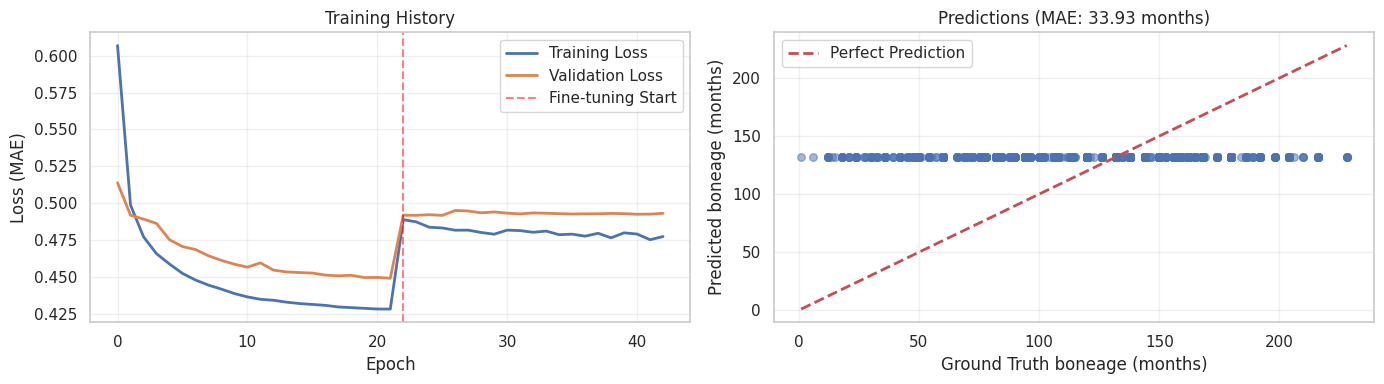

✓ Visualization saved


In [28]:
# ============================================================================
# VISUALIZATION
# ============================================================================

if csv_path and csv_path.exists():
    # Training history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Combine history from both phases
    all_loss = history_phase1.history['loss'] + history_phase2.history['loss']
    all_val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
    
    axes[0].plot(all_loss, label='Training Loss', linewidth=2)
    axes[0].plot(all_val_loss, label='Validation Loss', linewidth=2)
    axes[0].axvline(len(history_phase1.history['loss']), color='red', linestyle='--', alpha=0.5, label='Fine-tuning Start')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MAE)')
    axes[0].set_title('Training History')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Predictions vs Ground Truth
    lbl = globals().get('label_col', 'age_months')
    axes[1].scatter(y_true, y_pred, alpha=0.5, s=30)
    axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[1].set_xlabel(f'Ground Truth {lbl} (months)')
    axes[1].set_ylabel(f'Predicted {lbl} (months)')
    axes[1].set_title(f'Predictions (MAE: {mae:.2f} months)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'evaluation_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print('✓ Visualization saved')

In [4]:
# ============================================================================
# GRAD-CAM VISUALIZATION
# ============================================================================

# Check that all dependencies are available
required_vars = ['csv_path', 'model', 'backbone', 'val_df', 'IMAGE_SIZE', 'OUTPUT_DIR', 'TARGET_NORMALIZE']
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f'❌ Cannot run Grad-CAM: missing variables: {", ".join(missing_vars)}')
    print('   Please run all previous cells first (cells 1-14) in order.')
else:
    def denormalize_target(value):
        if TARGET_NORMALIZE:
            return value * float(globals().get('target_std', 1.0)) + float(globals().get('target_mean', 0.0))
        return value

    def find_last_conv_layer(model):
        for layer in reversed(model.layers):
            if isinstance(layer, layers.Conv2D):
                return layer.name
        for layer in reversed(model.layers):
            if hasattr(layer, 'layers'):
                for sublayer in reversed(layer.layers):
                    if isinstance(sublayer, layers.Conv2D):
                        return sublayer.name
        raise ValueError('No Conv2D layer found for Grad-CAM')

    def make_gradcam_heatmap(img_array, model, backbone_model, last_conv_layer_name):
        # Get the Conv2D layer from backbone
        conv_layer = backbone_model.get_layer(last_conv_layer_name)
        
        # Create intermediate model that outputs both conv layer and backbone output
        backbone_intermediate = keras.Model(
            inputs=backbone_model.input,
            outputs=[conv_layer.output, backbone_model.output]
        )
        
        # Rebuild grad_model by tracing through main model layers manually
        inputs = model.input
        x = model.layers[1](inputs)  # Rescaling layer
        conv_outputs, backbone_outputs = backbone_intermediate(x)
        
        # Continue from backbone output through remaining layers
        x = backbone_outputs
        for layer in model.layers[3:]:  # GlobalAveragePooling2D onwards
            x = layer(x)
        
        predictions = x
        
        grad_model = keras.Model(
            inputs=model.input,
            outputs=[conv_outputs, predictions]
        )
        
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)
            loss = predictions[:, 0]
        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
        heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
        return heatmap.numpy()

    if csv_path and csv_path.exists():
        sample_idx = int(np.random.randint(0, len(val_df)))
        sample_row = val_df.iloc[sample_idx]
        sample_path = sample_row['image_path']
        sample_label_raw = float(sample_row[globals().get('label_col', 'age_months')])
        sample_label = denormalize_target(sample_label_raw)
        
        # Load sample image the same way as the dataset pipeline
        sample_image = tf.io.read_file(sample_path)
        sample_image = tf.image.decode_png(sample_image, channels=1)
        sample_image = tf.image.convert_image_dtype(sample_image, tf.float32)
        sample_image = tf.image.grayscale_to_rgb(sample_image)
        sample_image = tf.image.resize(sample_image, IMAGE_SIZE)
        sample_for_model = tf.expand_dims(sample_image, axis=0)
        
        last_conv_layer_name = find_last_conv_layer(backbone)
        heatmap = make_gradcam_heatmap(sample_for_model, model, backbone, last_conv_layer_name)
        
        # Resize heatmap to the image size and overlay it
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMAGE_SIZE).numpy().squeeze()
        heatmap_resized = np.uint8(255 * heatmap_resized)
        cmap = plt.get_cmap('jet')
        heatmap_rgba = cmap(heatmap_resized / 255.0)
        heatmap_rgb = np.uint8(heatmap_rgba[..., :3] * 255)
        overlay = np.uint8(0.55 * (sample_image.numpy() * 255) + 0.45 * heatmap_rgb)
        
        pred_scaled = model.predict(sample_for_model, verbose=0).flatten()[0]
        pred_label = denormalize_target(float(pred_scaled))
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].imshow(sample_image.numpy())
        axes[0].set_title('Original')
        axes[0].axis('off')
        axes[1].imshow(heatmap, cmap='jet')
        axes[1].set_title('Grad-CAM Heatmap')
        axes[1].axis('off')
        axes[2].imshow(overlay.astype(np.uint8))
        axes[2].set_title(f'Overlay | True: {sample_label:.1f} | Pred: {pred_label:.1f}')
        axes[2].axis('off')
        plt.tight_layout()
        gradcam_path = OUTPUT_DIR / 'gradcam_example.png'
        plt.savefig(gradcam_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'✓ Grad-CAM saved: {gradcam_path}')

❌ Cannot run Grad-CAM: missing variables: csv_path, model, backbone, val_df, IMAGE_SIZE, OUTPUT_DIR, TARGET_NORMALIZE
   Please run all previous cells first (cells 1-14) in order.


In [ ]:
# ============================================================================
# SAVE MODEL & RESULTS
# ============================================================================

if csv_path and csv_path.exists():
    # Save model
    model.save(FINAL_MODEL_PATH)
    print(f'✓ Model saved: {FINAL_MODEL_PATH}')
    
    # Save results summary
    lbl = globals().get('label_col', 'age_months')
    target_mean = float(globals().get('target_mean', 0.0))
    target_std = float(globals().get('target_std', 1.0))
    results_dict = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Total_Samples': len(val_df),
        'Batch_Size': BATCH_SIZE,
        'Epochs': EPOCHS_INITIAL + EPOCHS_FINETUNE,
        'Initial_LR': INITIAL_LR,
        'Finetune_LR': FINETUNE_LR,
        'Label_Column': lbl,
        'Target_Mean': target_mean,
        'Target_Std': target_std,
        'Target_Normalized': TARGET_NORMALIZE,
    }
    
    results_df = pd.DataFrame([results_dict])
    results_df.to_csv(OUTPUT_DIR / 'results_summary.csv', index=False)
    print(f'✓ Results summary saved')
    print(f'\nResults:\n{results_df.to_string(index=False)}')